In [41]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import compute_S_rate
import auxiliary_functions

In [42]:
with open('gridsearch_results/block2activities_snapshots/gridsearch_results.pkl', 'rb') as handle:
    results = pickle.load(handle)

In [43]:
results

{'lambdas': array([1.00000000e-05, 3.59381366e-05, 1.29154967e-04, 4.64158883e-04,
        1.66810054e-03, 5.99484250e-03, 2.15443469e-02, 7.74263683e-02,
        2.78255940e-01, 1.00000000e+00]),
 'windows': array([5.]),
 'margin': 1.0,
 'sample_fraction': 1.0,
 'kernel': 'linear',
 'num_samples': 5,
 'num_lambda_jobs': 10,
 'num_parameter_pairs': 10,
 'save_signals': True,
 'signals_outdir': './gridsearch_results/block2activities_snapshots/signals',
 'selection_metric': 'hausdorff',
 'selection_array': array([[0.6],
        [0.6],
        [0.6],
        [0.6],
        [0.6],
        [0.6],
        [0.4],
        [5.2],
        [5.4],
        [3.8]]),
 'score_array': array([[0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.6],
        [0. ],
        [0.2],
        [0. ]]),
 'f1_array': array([[0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.4],
        [0.6],
        [0. ],
        [0.2],
        [0. ]]),
 'hausdo

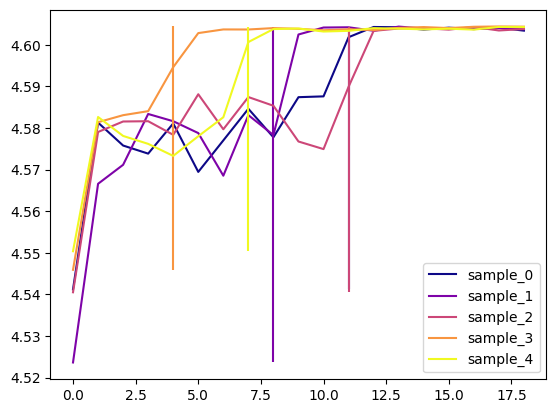

In [ ]:
lambdas = results['lambdas']
windows = results['windows']
lamda = lambdas[results['best_index'][0]]
window = windows[results['best_index'][1]]

colors = auxiliary_functions.generate_plasma_colors(len(range(5)))
for sample in range(5):
    with open('block2activities_snapshots.pkl', 'rb') as handle:
        tnet = pickle.load(handle)[sample]
        bkp = float(tnet['bkp'])

    with open(f'gridsearch_results/block2activities_snapshots/signals/sample_{sample}/signal_lamda_{lamda:.11f}_window_{window:g}.pkl', 'rb') as handle:
        signal = pickle.load(handle)

    plt.plot(signal['signal'], colors[sample], label=f'sample_{sample}')
    plt.vlines(tnet['bkp'], color=colors[sample], ymin=np.min(signal['signal']), ymax=np.max(signal['signal']))

#plt.vlines(results['lambda_results'][lamda]['detected_bkps'], color='black', linestyle='dashed', label='best lambda')
plt.legend()

In [60]:
results['lambda_results'][results['best_index'][0]]['predicted_change_points'][window]

[[11], [9], [12], [4], [7]]

In [63]:
list_bkp = []
for sample in range(5):
    with open('block2activities_snapshots.pkl', 'rb') as handle:
        tnet = pickle.load(handle)[sample]
        bkp = float(tnet['bkp'])
        list_bkp.append(bkp)

In [64]:
print(list_bkp)

[11.0, 8.0, 11.0, 4.0, 7.0]
